# Prueba de la API NASA POWER
Este notebook extrae datos históricos de precipitación y temperatura de la cuenca del Río Paute (Ecuador), donde se encuentran las principales centrales hidroeléctricas como Mazar y Paute.

**API Endpoint Oficial:** [NASA POWER Data Access Viewer](https://power.larc.nasa.gov/data-access-viewer/)

In [1]:
import urllib.request
import json
import pandas as pd
import matplotlib.pyplot as plt

# Coordenadas de la cuenca del Paute
lat = -2.75
lon = -78.50

# Fecha de inicio y fin (Todo Enero 2024)
start_date = '20240101'
end_date = '20240131'

# T2M = Temperatura a 2 metros, PRECTOTCORR = Precipitación
parameters = 'T2M,PRECTOTCORR'
url = f'https://power.larc.nasa.gov/api/temporal/daily/point?parameters={parameters}&community=RE&longitude={lon}&latitude={lat}&start={start_date}&end={end_date}&format=JSON'

print(f'Consultando API: {url}')
with urllib.request.urlopen(url) as response:
    if response.status == 200:
        data = json.loads(response.read().decode())
        print('\n✅ Datos descargados correctamente desde los servidores de la NASA.')
    else:
        print('Error en la conexión.')

Consultando API: https://power.larc.nasa.gov/api/temporal/daily/point?parameters=T2M,PRECTOTCORR&community=RE&longitude=-78.5&latitude=-2.75&start=20240101&end=20240131&format=JSON

✅ Datos descargados correctamente desde los servidores de la NASA.


### Transformación a DataFrame (Pandas)
Convertimos el JSON crudo en una tabla estructurada para analizar los datos más fácilmente.

In [2]:
temperaturas = data['properties']['parameter']['T2M']
precipitaciones = data['properties']['parameter']['PRECTOTCORR']

df = pd.DataFrame({
    'Temperatura_C': list(temperaturas.values()),
    'Precipitacion_mm': list(precipitaciones.values())
})

# Formatear el índice como tipo Fecha (Datetime)
df.index = pd.to_datetime(list(temperaturas.keys()), format='%Y%m%d')
df.index.name = 'Fecha'

# Mostrar los primeros 10 registros
df.head(10)

,Temperatura_C,Precipitacion_mm
Fecha,,
2024-01-01,13.35,1.49
2024-01-02,14.16,0.23
2024-01-03,13.45,3.04
2024-01-04,13.31,3.74
2024-01-05,13.16,4.76
2024-01-06,12.75,0.91
2024-01-07,12.31,0.02
2024-01-08,13.10,0.32
2024-01-09,12.99,2.76


### Visualización de los Datos
Graficamos la lluvia y la temperatura para ver su comportamiento durante el mes.

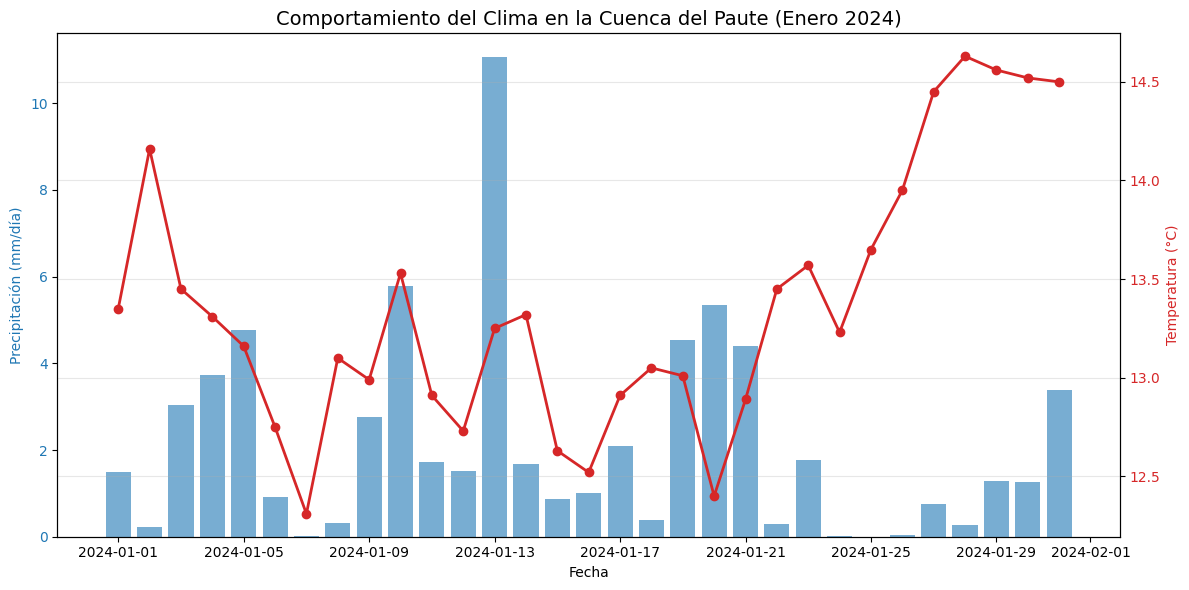

In [3]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Fecha')
ax1.set_ylabel('Precipitación (mm/día)', color='tab:blue')
ax1.bar(df.index, df['Precipitacion_mm'], color='tab:blue', alpha=0.6, label='Lluvia')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Temperatura (°C)', color='tab:red')
ax2.plot(df.index, df['Temperatura_C'], color='tab:red', marker='o', linestyle='-', linewidth=2, label='Temperatura')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Comportamiento del Clima en la Cuenca del Paute (Enero 2024)', fontsize=14)
fig.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()